<a href="https://colab.research.google.com/github/pmatkowska94/MSC_Data_Science/blob/main/Copy_of_iPSC_transfer_knowledge_tl1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import joblib
from sklearn.preprocessing import OrdinalEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf

training and val on small scale, test on big

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_df_ipsc.csv to test_df_ipsc.csv
Saving train1_df_ipsc.csv to train1_df_ipsc.csv
Saving val1_df_ipsc.csv to val1_df_ipsc.csv


In [ ]:
train_df_ipsc = pd.read_csv('train1_df_ipsc.csv')
test_df_ipsc = pd.read_csv('test_df_ipsc.csv')
val_df_ipsc = pd.read_csv('val1_df_ipsc.csv')

In [ ]:
colours = {
    'hist_bar': '#6A0DAD',
    'line_exp': '#2E2E2E',
    'line_model': '#4B0082',
    'ci_fill': '#D1C4E9',
    'axes': '#2E2E2E',
    'grid': '#DADADA',
    'background': '#FFFFFF',
    'text': '#1C1C1C'
}

In [ ]:
plt.rcParams.update({
    'figure.facecolor': colours['background'],
    'axes.facecolor': colours['background'],
    'axes.edgecolor': colours['axes'],
    'axes.labelcolor': colours['text'],
    'xtick.color': colours['text'],
    'ytick.color': colours['text'],
    'grid.color': colours['grid'],
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'text.color': colours['text'],
    'axes.titlecolor': colours['text'],
})

In [ ]:
sns.set_style('whitegrid', {
    'axes.facecolor': '#FFFFFF',
    'grid.color': '#DADADA',
    'axes.edgecolor': '#2E2E2E',
    'text.color': '#1C1C1C'
})

In [ ]:
np.random.seed(42)

def augment_sequence (df_group, noise = 0.05):
  aug_df_ipsc = df_group.copy()
  for col in ['p_v', 'vvm', 'tip_speed', 'reynolds']:
    aug_df_ipsc[col] += aug_df_ipsc[col] * np.random.uniform(-noise, noise)
  return aug_df_ipsc

In [ ]:
train_df_ipsc['group_id'] = train_df_ipsc.groupby(['p_id', 'r_id', 'clone_id', 'group_volume']).ngroup()

train_aug_ipsc = []

for group_id, df_group in train_df_ipsc.groupby('group_id'):
    for i in range(2):
        augmented = augment_sequence(df_group)
        augmented['group_id'] = f'{group_id}_aug{i}'
        train_aug_ipsc.append(augmented)
train_df_ipsc['group_id'] = train_df_ipsc['group_id'].astype(str)
train_aug_ipsc = pd.concat([train_df_ipsc] + train_aug_ipsc, ignore_index=True)

train_aug_ipsc.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,reynolds,aspect_r,group_volume,seed_d,cell_type,group_id
0,1.0,1.0,PN12.48,0.000000,0.3000,0.150,0.915912,0.0,0.153938,1946.28,1.51,0.5,0.3,ipsc,0
1,1.0,1.0,PN12.48,1.000000,0.0446,0.153,0.897953,0.0,0.153938,1946.28,1.51,0.5,0.3,ipsc,0
2,1.0,1.0,PN12.48,1.791667,0.0698,0.156,0.880684,0.0,0.153938,1946.28,1.51,0.5,0.3,ipsc,0
3,1.0,1.0,PN12.48,2.809167,0.3040,0.165,0.957351,0.0,0.161268,2038.96,1.51,0.5,0.3,ipsc,0
4,1.0,1.0,PN12.48,3.906250,0.6090,0.185,1.108534,0.0,0.175929,2224.32,1.51,0.5,0.3,ipsc,0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cell_type_enc.joblib to cell_type_enc.joblib


In [ ]:
enc = joblib.load('cell_type_enc.joblib')

In [ ]:
Xohe_ipsc = enc.transform(train_aug_ipsc[['cell_type']])
ohe_cols = [f'cell_type_{c}' for c in enc.categories_[0]]
train_aug_ipsc[ohe_cols] = Xohe_ipsc

In [ ]:
test_df_ipsc[ohe_cols] = enc.transform(test_df_ipsc[['cell_type']])
val_df_ipsc[ohe_cols] = enc.transform(val_df_ipsc[['cell_type']])

In [ ]:
def truncate_peak_plus_buffer(df, group_cols, buffer=2):
    d = df.sort_values(group_cols + ['time']).copy()
    out, removed = [], 0
    for _, g in d.groupby(group_cols, sort=False):
        peak_idx = g['vcd'].idxmax()
        peak_t = g.loc[peak_idx, 'time']
        kept = g[g['time'] <= peak_t + buffer]
        removed += len(g) - len(kept)
        out.append(kept)
    res = pd.concat(out, ignore_index=True)
    print(f"[truncate] before={len(d)} after={len(res)} removed={removed}")
    return res

group_cols = ['p_id','r_id','clone_id','group_volume', 'group_id']
val_df_ipsc['group_id'] = 1
test_df_ipsc['group_id'] = 1
train_aug_ipsc = truncate_peak_plus_buffer(train_aug_ipsc, group_cols, buffer=2)
val_df_ipsc    = truncate_peak_plus_buffer(val_df_ipsc,    group_cols, buffer=2)
test_df_ipsc   = truncate_peak_plus_buffer(test_df_ipsc,   group_cols, buffer=2)

[truncate] before=189 after=180 removed=9
[truncate] before=24 after=24 removed=0
[truncate] before=11 after=11 removed=0


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving scaler_combined_cho_ipsc_main_study.pkl to scaler_combined_cho_ipsc_main_study.pkl


In [ ]:
scaler = joblib.load("scaler_combined_cho_ipsc_main_study.pkl")

In [ ]:
static_cols = ['seed_d', 'cell_type_CHO', 'cell_type_iPSC']
num_cols = ['time', 'vcd', 'volume', 'p_v', 'vvm', 'tip_speed', 'aspect_r', 'reynolds', 'seed_d']
train_aug_ipsc[num_cols] = scaler.transform(train_aug_ipsc[num_cols])
test_df_ipsc[num_cols] = scaler.transform(test_df_ipsc[num_cols])
val_df_ipsc[num_cols] = scaler.transform(val_df_ipsc[num_cols])

In [ ]:
train_aug_ipsc.drop(columns='cell_type', inplace=True)
val_df_ipsc.drop(columns='cell_type', inplace=True)
test_df_ipsc.drop(columns='cell_type', inplace=True)

In [ ]:
group_cols = ['p_id', 'r_id', 'clone_id', 'group_volume', 'group_id']
feature_cols = [col for col in train_aug_ipsc.columns if col not in group_cols]

In [ ]:
def build_ar_sequences(df, group_cols, feature_cols, seed_col='seed_d', vcd_col='vcd'):
    X_list, y_list = [], []
    df_sorted = df.sort_values(group_cols + ['time'])
    other_cols = [c for c in feature_cols if c != vcd_col]

    for _, g in df_sorted.groupby(group_cols, sort=False):
        g = g.reset_index(drop=True)
        v = g[vcd_col].to_numpy().astype('float32')
        seed = g[seed_col].iloc[0]
        v_prev = np.concatenate([[seed], v[:-1]]).astype('float32')
        other = g[other_cols].to_numpy().astype('float32')
        X = np.concatenate([other, v_prev[:, None]], axis=1)
        y = v[:, None]
        X_list.append(X)
        y_list.append(y)
    return X_list, y_list

In [ ]:
ar_X_train, ar_y_train = build_ar_sequences(train_aug_ipsc, group_cols, feature_cols)
ar_X_val,   ar_y_val   = build_ar_sequences(val_df_ipsc,    group_cols, feature_cols)
ar_X_test,  ar_y_test  = build_ar_sequences(test_df_ipsc,   group_cols, feature_cols)

In [ ]:
for i, (x_seq, y_seq) in enumerate(zip(ar_X_train, ar_y_train)):
    print(f"X shape = {x_seq.shape}, y shape = {y_seq.shape}")

X shape = (7, 11), y shape = (7, 1)
X shape = (7, 11), y shape = (7, 1)
X shape = (7, 11), y shape = (7, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (11, 11), y shape = (11, 1)
X shape = (6, 11), y shape = (6, 1)
X shape = (6, 11), y shape = (6, 1)
X shape = (6, 11), y shape = (6, 1)
X shape = (7, 11), y shape = (7, 1)
X shape = (7, 11), y shape = (7, 1)
X shape = (7, 11), y shape = (7, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (10, 11), y shape = (10, 1)
X shape = (8, 11), y shape = (8, 1)
X shape = (8, 11), y shape = (8, 1)
X shape = (8, 11), y shape = (8, 1)
X shape = (6, 11), y shape = (6, 1)
X shape = (6, 11), y shape = (6, 1)
X shape = (6, 11), y shape = (6, 1)
X shape = (5, 11), y shape = (5, 1)
X shape = (5, 11), y shape = (5, 1)
X shape = (5, 11), y shape = (5, 1)


In [ ]:
def trim_pad(X_list, y_list, max_len, pad):
    X_list = [x[:max_len, :] for x in X_list]
    y_list = [np.asarray(y, dtype='float32')[:max_len].reshape(-1, 1) for y in y_list]

    X = tf.ragged.constant(X_list).to_tensor(default_value=pad,shape=[None,max_len, X_list[0].shape[1]])
    y = tf.ragged.constant(y_list).to_tensor(default_value=pad,shape=[None, max_len, 1])
    return X, y

In [ ]:
max_len = 11
pad = -2.0

X_train, y_train = trim_pad(ar_X_train, ar_y_train, max_len, pad)
X_val,   y_val   = trim_pad(ar_X_val,   ar_y_val,   max_len, pad)
X_test,  y_test  = trim_pad(ar_X_test,  ar_y_test,  max_len, pad)

In [ ]:
X_train, y_train = X_train.numpy(), y_train.numpy()
X_val,   y_val   = X_val.numpy(),   y_val.numpy()
X_test,  y_test  = X_test.numpy(),  y_test.numpy()

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)

(24, 11, 11)
(2, 11, 11)
(2, 11, 1)


In [ ]:
def build_sample_weights(y, pad_value=-2.0, k=1):
    y2 = np.squeeze(y, axis=-1)
    valid = (y2 != pad_value)
    T = y2.shape[1]
    after_k = np.arange(T)[None, :] >= k
    return (valid & after_k).astype('float32')

sw_train = build_sample_weights(y_train, pad, k=1)
sw_val   = build_sample_weights(y_val,   pad, k=1)
sw_test  = build_sample_weights(y_test,  pad, k=1)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving model_main_study.keras to model_main_study.keras


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('model_main_study.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 14, 11)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 14, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 14, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 14, 32)         │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 14, 64)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,725 (401.27 KB)

 Trainable params: 34,241 (133.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 68,484 (267.52 KB)

In [ ]:
for layer in model.layers:
  if layer.name in ['lstm_1', 'layer_normalization_1', 'dense', 'dense_1']:
    layer.trainable = True
  else:
    layer.trainable = False

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='mse', metrics=['mae'])

In [ ]:
early_stop = EarlyStopping(patience=100, restore_best_weights=True)

history_tl1 = model.fit(
    X_train, y_train,
    sample_weight=sw_train,
    validation_data=(X_val, y_val, sw_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 741ms/step - loss: 0.0860 - mae: 0.6151 - val_loss: 0.0427 - val_mae: 0.5357
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0489 - mae: 0.6202 - val_loss: 0.0423 - val_mae: 0.5343
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0534 - mae: 0.5971 - val_loss: 0.0418 - val_mae: 0.5330
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0639 - mae: 0.5912 - val_loss: 0.0414 - val_mae: 0.5317
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0480 - mae: 0.5634 - val_loss: 0.0409 - val_mae: 0.5303
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0532 - mae: 0.5686 - val_loss: 0.0405 - val_mae: 0.5290
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0522 - mae: 0.5985 - val_loss: 0.0400 - val_mae: 0.5277
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0557 - mae: 0.6099 - val_loss: 0.0396 - val_mae: 0.5264
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0807 - mae:

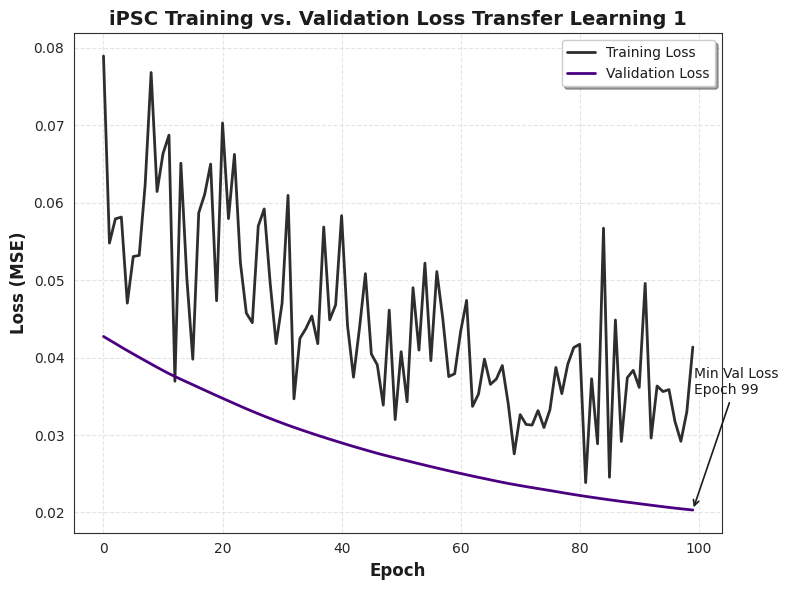

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history_tl1.history['loss'],
         label='Training Loss',
         linewidth=2,
         color=colours["line_exp"])

plt.plot(history_tl1.history['val_loss'],
         label='Validation Loss',
         linewidth=2,
         color=colours['line_model'])

plt.xlabel('Epoch', fontsize=12, fontweight='bold', color=colours['text'])
plt.ylabel('Loss (MSE)', fontsize=12, fontweight='bold', color=colours['text'])
plt.title('iPSC Training vs. Validation Loss Transfer Learning 1', fontsize=14, fontweight='bold', color=colours['text'])
plt.legend(fontsize=10, frameon=True, shadow=True, loc='upper right')
plt.grid(True, color=colours["grid"], linestyle='--', alpha=0.7)
plt.gca().set_facecolor(colours["background"])

best_epoch = np.argmin(history_tl1.history['val_loss'])
best_val = history_tl1.history['val_loss'][best_epoch]

plt.annotate(
    f'Min Val Loss\nEpoch {best_epoch}',
    xy=(best_epoch, best_val),
    xytext=(best_epoch +0.25, best_val + 0.015),
    arrowprops=dict(color=colours['text'], arrowstyle='->', lw=1.2),
    fontsize=10,
    color=colours['text']
)
plt.tight_layout()

In [ ]:
model.evaluate(X_test, y_test, sample_weight=sw_test)
predicted_vcd = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0047 - mae: 0.6814
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step


In [ ]:
valid = (y_test[..., 0] != pad)

for i in range(predicted_vcd.shape[0]):
    idx = np.where(valid[i])[0]
    if idx.size:
        j = idx[0]
        predicted_vcd[i, j, 0] = y_test[i, j, 0]

predicted_vcd = predicted_vcd.squeeze(-1)
y_test = y_test.squeeze(-1)

In [ ]:
n_samples, time_steps = predicted_vcd.shape
vcd_idx = list(scaler.feature_names_in_).index('vcd')

flat_pred = predicted_vcd.flatten()
flat_true = y_test.flatten()

dummy_pred = np.zeros((n_samples * time_steps, len(scaler.feature_names_in_)))
dummy_true = np.zeros_like(dummy_pred)

dummy_pred[:, vcd_idx] = flat_pred
dummy_true[:, vcd_idx] = flat_true

inv_pred = scaler.inverse_transform(dummy_pred)[:, vcd_idx]
inv_true = scaler.inverse_transform(dummy_true)[:, vcd_idx]

vcd_pred_original = inv_pred.reshape(n_samples, time_steps)
vcd_true_original = inv_true.reshape(n_samples, time_steps)

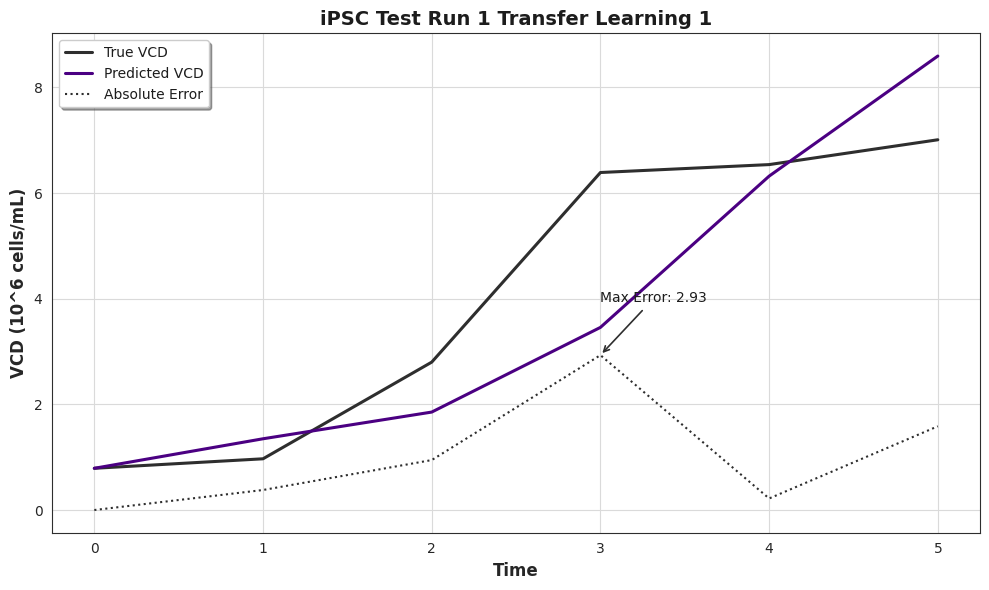

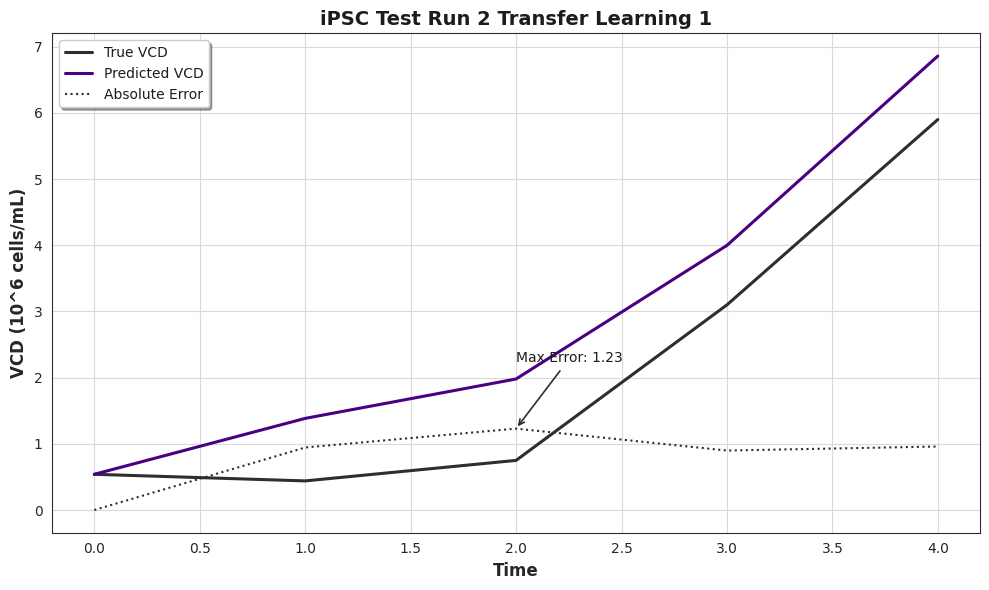

In [ ]:
for i in range(n_samples):
    mask = y_test[i] != -2.0
    time_points = np.arange(sum(mask))
    true_vals = vcd_true_original[i][mask]
    pred_vals = vcd_pred_original[i][mask]
    abs_error = np.abs(true_vals - pred_vals)

    plt.figure(figsize=(10, 6))

    plt.plot(
        time_points, true_vals,
        label='True VCD',
        linewidth=2.2,
        color=colours["line_exp"]
    )

    plt.plot(
        time_points, pred_vals,
        label='Predicted VCD',
        linewidth=2.2,
        color=colours["line_model"]
    )

    plt.plot(
        time_points, abs_error,
        label='Absolute Error',
        color=colours["axes"],
        linestyle=':'
    )

    max_idx = np.argmax(abs_error)
    plt.annotate(
        f"Max Error: {abs_error[max_idx]:.2f}",
        xy=(time_points[max_idx], abs_error[max_idx]),
        xytext=(time_points[max_idx], abs_error[max_idx] + 1),
        arrowprops=dict(arrowstyle="->", color=colours["axes"], lw=1.2),
        fontsize=10,
        color=colours["text"]
    )

    plt.title(f'iPSC Test Run {i+1} Transfer Learning 1', fontsize=14, fontweight='bold')
    plt.xlabel('Time', fontsize=12, fontweight='bold')
    plt.ylabel('VCD (10^6 cells/mL)', fontsize=12, fontweight='bold')
    plt.legend(fontsize=10, frameon=True, shadow=True, loc='best')
    plt.grid(True)
    plt.gca().set_facecolor(colours["background"])
    plt.tight_layout()

In [ ]:
mask = y_test != -2.0

masked_true = vcd_true_original[mask]
masked_pred = vcd_pred_original[mask]

mse = mean_squared_error(masked_true, masked_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(masked_true, masked_pred)

print(f"Test RMSE= {rmse:.2f} 10^6 cells/mL")
print(f"Test MAE= {mae:.2f} 10^6 cells/mL")

Test RMSE= 1.22 10^6 cells/mL
Test MAE= 0.92 10^6 cells/mL


In [ ]:
rmse_p = (rmse / vcd_true_original.max()) * 100
mae_p = (mae / vcd_true_original.max()) * 100

print(f"RMSE = {rmse_p:.1f}% of the VCD max in test set.")
print(f"MAE = {mae_p:.1f}% of the VCD max in test set.")

RMSE = 17.4% of the VCD max in test set.
MAE = 13.1% of the VCD max in test set.


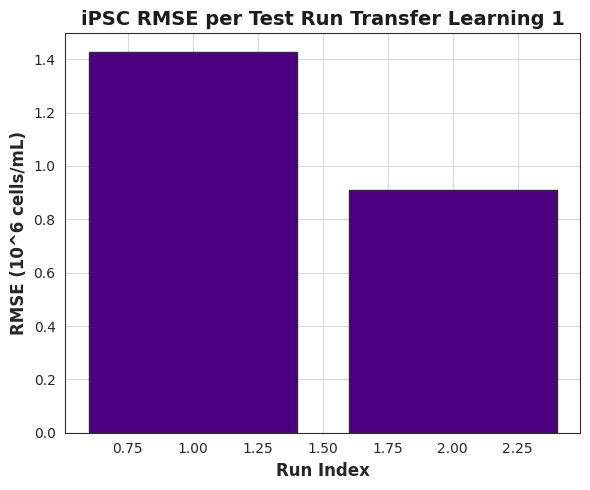

In [ ]:
rmse_per_run = []
mae_per_run = []

for i in range(n_samples):
    mask = y_test[i] != -2.0
    true_vals = vcd_true_original[i][mask]
    pred_vals = vcd_pred_original[i][mask]

    rmse_i = np.sqrt(np.mean((true_vals - pred_vals)**2))
    mae_i = np.mean(np.abs(true_vals - pred_vals))

    rmse_per_run.append(rmse_i)
    mae_per_run.append(mae_i)

plt.figure(figsize=(6,5))
plt.bar(np.arange(1, n_samples+1), rmse_per_run, color=colours['line_model'], edgecolor=colours['axes'])
plt.title('iPSC RMSE per Test Run Transfer Learning 1', fontsize=14, fontweight='bold')
plt.xlabel('Run Index', fontsize=12, fontweight='bold')
plt.ylabel('RMSE (10^6 cells/mL)', fontsize=12, fontweight='bold')
plt.grid(True)
plt.tight_layout()

In [ ]:
group = test_df_ipsc.groupby(group_cols).first().reset_index()

errors = []
for i in range(len(vcd_true_original)):
    true_vals = vcd_true_original[i]
    pred_vals = vcd_pred_original[i]
    mask = y_test[i] != -2.0
    mae = mean_absolute_error(true_vals[mask], pred_vals[mask])
    rmse = np.sqrt(np.mean((true_vals[mask] - pred_vals[mask]) ** 2))


    errors.append({'group_index': i, 'MAE': mae, 'RMSE': rmse})

error_df = pd.DataFrame(errors)

group_with_error = pd.concat([group, error_df], axis=1)

summary = group_with_error.groupby('group_volume')[['MAE', 'RMSE']].mean().sort_values('MAE')

print(summary)

                   MAE      RMSE
group_volume                    
5.0           0.806619  0.909290
6.0           1.010119  1.425764


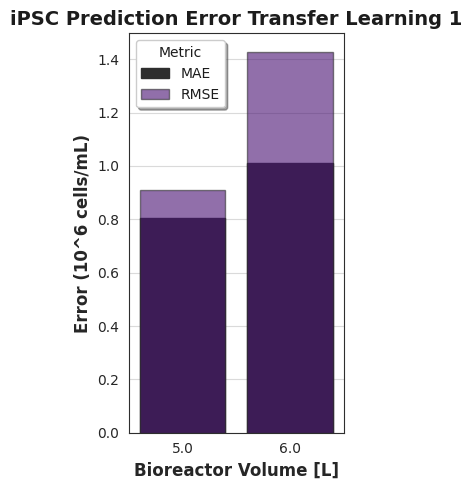

In [ ]:
plt.figure(figsize=(3, 5))

sns.barplot(data=summary.reset_index(), x='group_volume', y='MAE',
            color=colours['line_exp'], edgecolor=colours['axes'], label='MAE')
sns.barplot( data=summary.reset_index(), x='group_volume', y='RMSE',
            color=colours['line_model'], edgecolor=colours['axes'], alpha=0.6, label='RMSE')

plt.title('iPSC Prediction Error Transfer Learning 1', fontsize=14, fontweight='bold')
plt.xlabel('Bioreactor Volume [L]', fontsize=12, fontweight='bold')
plt.ylabel('Error (10^6 cells/mL)', fontsize=12, fontweight='bold')
plt.legend(title='Metric', fontsize=10, frameon=True, shadow=True)
plt.grid(True, axis = 'y')
plt.tight_layout()

In [ ]:
model.save('model_main_study_tl1_low_LR.keras')
files.download('model_main_study_tl1_low_LR.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data = {
    "Stage": [
        "Zero-shot baseline",
        "Zero-shot (correct inference)",
        "TL1 (reduced LR)"
    ],
    "Model": [
        "CHO → iPSC",
        "CHO → iPSC",
        "CHO → iPSC"
    ],
    "RMSE (%max)": [36.3, 17.4, 17.4],
    "MAE (%max)": [27.9, 11.3, 13.1]
}

df_tl = pd.DataFrame(data)
df_tl

,Stage,Model,RMSE (%max),MAE (%max)
0,Zero-shot baseline,CHO → iPSC,36.3,27.9
1,Zero-shot (correct inference),CHO → iPSC,17.4,11.3
2,TL1 (reduced LR),CHO → iPSC,17.4,13.1


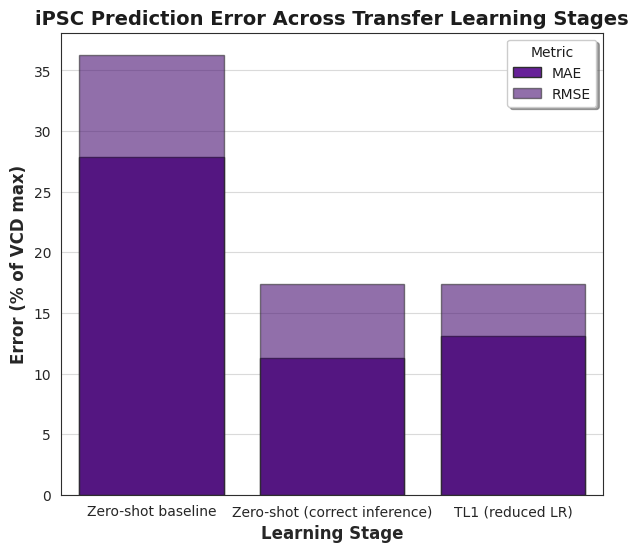

In [ ]:
plt.figure(figsize=(7, 6))

sns.barplot(
    data=df_tl,
    x='Stage', y='MAE (%max)',
    color=colours['hist_bar'], edgecolor=colours['axes'],
    label='MAE'
)

sns.barplot(
    data=df_tl,
    x='Stage', y='RMSE (%max)',
    color=colours['line_model'], edgecolor=colours['axes'],
    alpha=0.6, label='RMSE'
)

plt.title("iPSC Prediction Error Across Transfer Learning Stages",fontsize=14, fontweight='bold')
plt.xlabel("Learning Stage", fontsize=12, fontweight='bold')
plt.ylabel("Error (% of VCD max)", fontsize=12, fontweight='bold')

plt.legend(title="Metric", fontsize=10, frameon=True, shadow=True)
plt.grid(True, axis='y')